In [ ]:
import sys
import os
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, log_loss
from sklearn.model_selection import GroupShuffleSplit

sys.path.append(os.path.abspath('..'))
from src.data_preprocessing import get_modeling_datasets
from src.models import PALModel

# 1. Load the STRICTLY SEPARATED modeling datasets
train_imp, test_imp, dqa_imp = get_modeling_datasets()

print(f"Standard Train Size: {len(train_imp)}")
print(f"Standard Test Size: {len(test_imp)}")
print(f"DQA Subset Size: {len(dqa_imp)}")

c:\Users\kooij\Desktop\DS_Master\Thesis\Thesis_masters\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Downloading/Loading Qilin from HuggingFace...


Flattening modeling splits to impression level...
Standard Train Size: 841675
Standard Test Size: 128191
DQA Subset Size: 27656


In [ ]:
# Create GroupShuffleSplit object
gss_train_valtest = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=42)
gss_val_test = GroupShuffleSplit(n_splits=1, test_size=0.50, random_state=42) # Splits the 20% into 10/10

# 1. Split Train vs (Val + Test) based on session_idx
train_idx, valtest_idx = next(gss_train_valtest.split(dqa_imp, groups=dqa_imp['session_idx']))
dqa_train = dqa_imp.iloc[train_idx].copy()
dqa_valtest = dqa_imp.iloc[valtest_idx].copy()

# 2. Split Val vs Test
val_idx, test_idx = next(gss_val_test.split(dqa_valtest, groups=dqa_valtest['session_idx']))
dqa_val = dqa_valtest.iloc[val_idx].copy()
dqa_test = dqa_valtest.iloc[test_idx].copy()

# Add a dummy DQA feature column (Always 1 for this subset)
for df in [dqa_train, dqa_val, dqa_test]:
    df['dqa_present'] = 1

print(f"DQA Train: {len(dqa_train)} | Val: {len(dqa_val)} | Test: {len(dqa_test)}")

DQA Train: 21984 | Val: 2861 | Test: 2811


### Logistic regressions

In [ ]:
def evaluate_lr(X_train, y_train, X_test, y_test, name="Baseline"):
    lr = LogisticRegression()
    lr.fit(X_train, y_train)
    probs = lr.predict_proba(X_test)[:, 1]
    
    auc = roc_auc_score(y_test, probs)
    loss = log_loss(y_test, probs)
    print(f"--- {name} Logistic Regression ---")
    print(f"ROC-AUC: {auc:.4f} | LogLoss: {loss:.4f}\n")
    return lr

# Standard LR Baseline
X_train_std = train_imp[['position', 'is_left_column']].fillna(0)
y_train_std = train_imp['click'].fillna(0)
X_test_std = test_imp[['position', 'is_left_column']].fillna(0)
y_test_std = test_imp['click'].fillna(0)

lr_std = evaluate_lr(X_train_std, y_train_std, X_test_std, y_test_std, "Standard")

# DQA LR Baseline
X_train_dqa = dqa_train[['position', 'is_left_column']].fillna(0)
y_train_dqa = dqa_train['click'].fillna(0)
X_test_dqa = dqa_test[['position', 'is_left_column']].fillna(0)
y_test_dqa = dqa_test['click'].fillna(0)

lr_dqa = evaluate_lr(X_train_dqa, y_train_dqa, X_test_dqa, y_test_dqa, "DQA-Present")

--- Standard Logistic Regression ---
ROC-AUC: 0.6065 | LogLoss: 0.5188

--- DQA-Present Logistic Regression ---
ROC-AUC: 0.6377 | LogLoss: 0.5073



### PAL models

In [ ]:
def evaluate_pal(model, test_df, use_dqa=False):
    model.eval()
    with torch.no_grad():
        # Evaluation can usually be done in one full batch since no gradients are stored
        pos_t = torch.tensor(test_df['position'].values, dtype=torch.long)
        left_t = torch.tensor(test_df['is_left_column'].astype(int).values, dtype=torch.float32)
        y_true = test_df['click'].values
        
        dqa_t = torch.tensor(test_df['dqa_present'].values, dtype=torch.float32) if use_dqa else None
        
        probs = model(pos_t, left_t, dqa_t).numpy()
        
        auc = roc_auc_score(y_true, probs)
        loss = log_loss(y_true, probs)
        
        return auc, loss

In [ ]:
from torch.utils.data import TensorDataset, DataLoader
import torch.optim as optim
import torch.nn as nn
import torch

def train_pal_refined(model, train_df, val_df, epochs=50, lr=0.005, weight_decay=1e-4, use_dqa=False, batch_size=256, model_name="model"):
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    criterion = nn.BCELoss()
    
    # Helper to create DataLoaders
    def get_loader(df):
        pos = torch.tensor(df['position'].values, dtype=torch.long)
        left = torch.tensor(df['is_left_column'].astype(int).values, dtype=torch.float32)
        y = torch.tensor(df['click'].values, dtype=torch.float32)
        if use_dqa:
            dqa = torch.tensor(df['dqa_present'].values, dtype=torch.float32)
            return DataLoader(TensorDataset(pos, left, dqa, y), batch_size=batch_size, shuffle=True)
        return DataLoader(TensorDataset(pos, left, y), batch_size=batch_size, shuffle=True)

    train_loader = get_loader(train_df)
    best_val_loss = float('inf')
    patience = 5
    counter = 0
    save_path = f'best_{model_name}.pth'

    model.train()
    for epoch in range(epochs):
        total_train_loss = 0
        for batch in train_loader:
            optimizer.zero_grad()
            if use_dqa:
                b_pos, b_left, b_dqa, b_y = batch
                preds = model(b_pos, b_left, b_dqa)
            else:
                b_pos, b_left, b_y = batch
                preds = model(b_pos, b_left)
            
            loss = criterion(preds, b_y)
            loss.backward()
            optimizer.step()
            total_train_loss += loss.item()

        # Validation Step
        val_auc, val_loss = evaluate_pal(model, val_df, use_dqa=use_dqa)
        
        if (epoch + 1) % 2 == 0:
            print(f"Epoch {epoch+1} | Train Loss: {total_train_loss/len(train_loader):.4f} | Val Loss: {val_loss:.4f} | Val AUC: {val_auc:.4f}")

        # Early Stopping
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            counter = 0
            torch.save(model.state_dict(), save_path)
        else:
            counter += 1
            if counter >= patience:
                print(f"--- Early stopping triggered for {model_name} ---")
                break
    
    model.load_state_dict(torch.load(save_path))
    return model

In [ ]:
print("=========================================")
print("STAGE 1: Training Standard PAL Baseline")
print("=========================================")

# 1. Prepare Validation split for Standard (to keep rigor consistent)
from sklearn.model_selection import train_test_split
std_train_sub, std_val = train_test_split(train_imp, test_size=0.1, random_state=42)

# 2. Initialize Model
global_max_std = int(max(train_imp['position'].max(), test_imp['position'].max()))
pal_standard = PALModel(max_position=global_max_std, use_dqa_feature=False)

# 3. Train
pal_standard = train_pal_refined(
    pal_standard, 
    std_train_sub, 
    std_val, 
    epochs=20, 
    lr=0.01, 
    batch_size=4096, # Large batch for large data
    model_name="pal_standard"
)

# 4. Final Test Evaluation
std_auc, std_loss = evaluate_pal(pal_standard, test_imp)
print(f"\nFINAL STANDARD PAL -> ROC-AUC: {std_auc:.4f} | LogLoss: {std_loss:.4f}")

STAGE 1: Training Standard PAL Baseline
Epoch 2 | Train Loss: 0.4757 | Val Loss: 0.4760 | Val AUC: 0.6634
Epoch 4 | Train Loss: 0.4756 | Val Loss: 0.4757 | Val AUC: 0.6642
Epoch 6 | Train Loss: 0.4755 | Val Loss: 0.4756 | Val AUC: 0.6647
Epoch 8 | Train Loss: 0.4754 | Val Loss: 0.4761 | Val AUC: 0.6642
Epoch 10 | Train Loss: 0.4754 | Val Loss: 0.4756 | Val AUC: 0.6643
--- Early stopping triggered for pal_standard ---

FINAL STANDARD PAL -> ROC-AUC: 0.6526 | LogLoss: 0.4896


In [ ]:
print("=========================================")
print("STAGE 2: Training DQA-Aware PAL Model")
print("=========================================")

# 1. Initialize Model
global_max_dqa = int(dqa_imp['position'].max())
pal_dqa = PALModel(max_position=global_max_dqa, use_dqa_feature=True)

# 2. Train using the specific DQA Val set we created earlier
pal_dqa = train_pal_refined(
    pal_dqa, 
    dqa_train, 
    dqa_val, 
    epochs=50, 
    lr=0.005, 
    weight_decay=1e-4, 
    use_dqa=True, 
    batch_size=256, # Small batch for small data
    model_name="pal_dqa"
)

# 3. Final Test Evaluation on unseen DQA test set
dqa_auc, dqa_loss = evaluate_pal(pal_dqa, dqa_test, use_dqa=True)
print(f"\nFINAL DQA-AWARE PAL -> ROC-AUC: {dqa_auc:.4f} | LogLoss: {dqa_loss:.4f}")

STAGE 2: Training DQA-Aware PAL Model
Epoch 2 | Train Loss: 0.4997 | Val Loss: 0.4851 | Val AUC: 0.5735
Epoch 4 | Train Loss: 0.4933 | Val Loss: 0.4821 | Val AUC: 0.6066
Epoch 6 | Train Loss: 0.4925 | Val Loss: 0.4820 | Val AUC: 0.6092
Epoch 8 | Train Loss: 0.4921 | Val Loss: 0.4816 | Val AUC: 0.6092
Epoch 10 | Train Loss: 0.4920 | Val Loss: 0.4821 | Val AUC: 0.6090
Epoch 12 | Train Loss: 0.4919 | Val Loss: 0.4824 | Val AUC: 0.6083
--- Early stopping triggered for pal_dqa ---

FINAL DQA-AWARE PAL -> ROC-AUC: 0.6435 | LogLoss: 0.5022


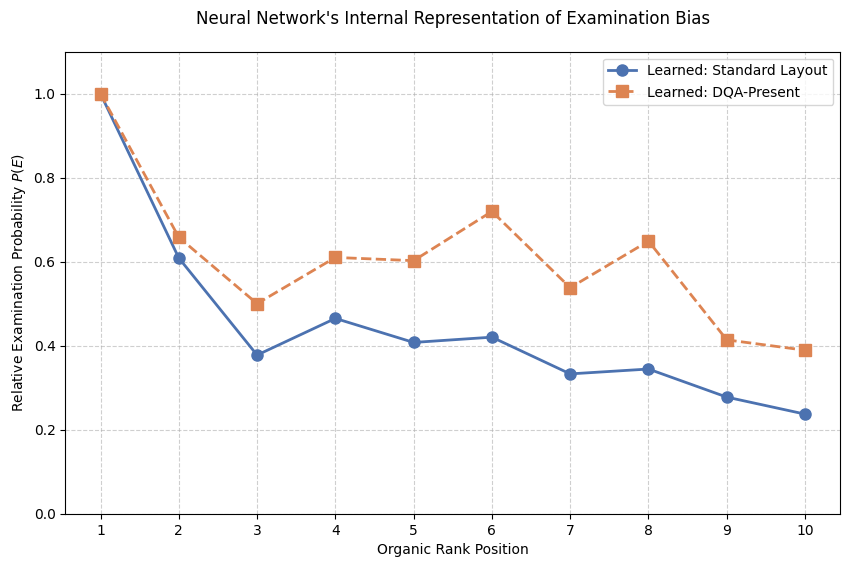

In [ ]:
import matplotlib.pyplot as plt
import torch

def get_learned_probabilities(model, max_pos=10):
    model.eval()
    positions = torch.arange(1, max_pos + 1)
    # Assume 'Left Column' (1) and 'DQA Present' (1) if applicable for the curve
    is_left = torch.ones(max_pos) 
    
    with torch.no_grad():
        pos_emb = model.pos_embedding(positions)
        # Construct features based on the model's specific pathway
        features = [pos_emb, is_left.unsqueeze(1)]
        
        if model.use_dqa_feature:
            # For the DQA model, we simulate a 'DQA Present' environment
            features.append(torch.ones(max_pos, 1))
            
        exam_input = torch.cat(features, dim=1)
        # The output of the MLP is P(E)
        prob_exam = model.exam_mlp(exam_input).numpy().flatten()
        
    # Normalize by the first position so Rank 1 = 1.0 (Same as SQ2)
    return prob_exam / prob_exam[0]

# Generate the comparison plot
plt.figure(figsize=(10, 6))

# Get curves from both trained models
standard_curve = get_learned_probabilities(pal_standard)
dqa_curve = get_learned_probabilities(pal_dqa)

plt.plot(range(1, 11), standard_curve, marker='o', markersize=8, 
         linestyle='-', linewidth=2, color='#4C72B0', label='Learned: Standard Layout')
plt.plot(range(1, 11), dqa_curve, marker='s', markersize=8, 
         linestyle='--', linewidth=2, color='#DD8452', label='Learned: DQA-Present')

plt.title("Neural Network's Internal Representation of Examination Bias", pad=20)
plt.xlabel("Organic Rank Position")
plt.ylabel("Relative Examination Probability $P(E)$")
plt.xticks(range(1, 11))
plt.ylim(0, 1.1)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.savefig('learned_bias_comparison.pdf', bbox_inches='tight')
plt.show()